In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
admissions = pd.read_csv(r'C:\Users\Warner_Beast\.cache\kagglehub\datasets\antusaha182352543\mimic-iv-clinical-text-data\versions\1\admissions.csv')

In [10]:
admissions_counts = admissions['admission_type'].value_counts()

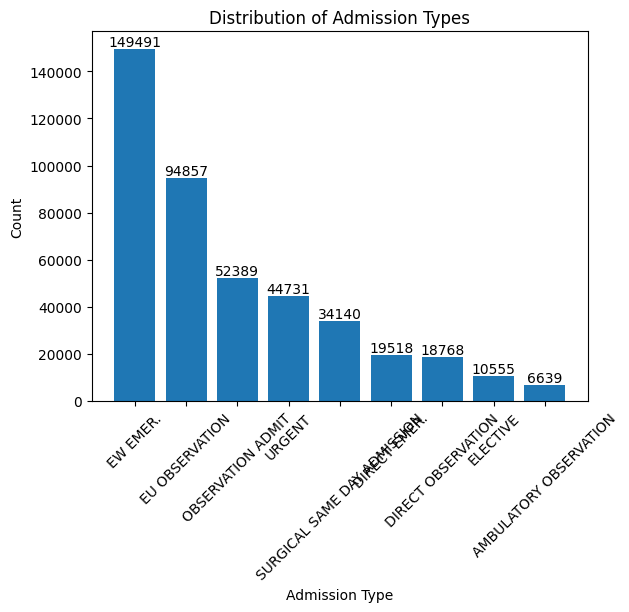

In [7]:
plt.figure()
bars = plt.bar(admissions_counts.index, admissions_counts.values)
plt.title("Distribution of Admission Types")
plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

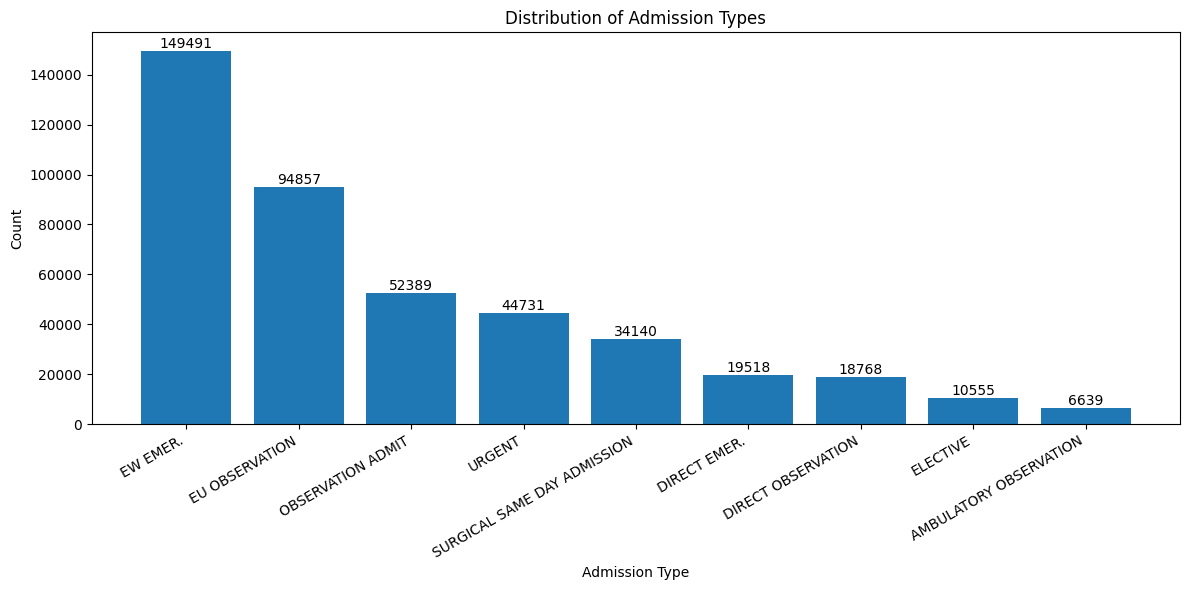

In [11]:
# Create larger figure for better visibility
plt.figure(figsize=(12, 6))
bars = plt.bar(admissions_counts.index, admissions_counts.values)


plt.title("Distribution of Admission Types")
plt.xlabel("Admission Type")
plt.ylabel("Count")

# Rotate labels for readability
plt.xticks(rotation=30, ha='right')

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [12]:
# Reload admissions and recreate 30-day readmission flag

# Load dataset
df = admissions

# Ensure datetime
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"] = pd.to_datetime(df["dischtime"], errors="coerce")

# Sort by patient and admit time
df = df.sort_values(["subject_id", "admittime"])

# Next admission per patient
df["next_admittime"] = df.groupby("subject_id")["admittime"].shift(-1)

# Days to readmission
df["days_to_readmit"] = (df["next_admittime"] - df["dischtime"]).dt.days

# 30-day readmission flag
df["readmit_30d_flag"] = (
    df["days_to_readmit"].between(1, 30, inclusive="both")
).astype(int)

# Filter readmissions only
df_readmit = df[df["readmit_30d_flag"] == 1]


# 1️⃣ Readmission count by Admission Type
readmit_by_admission_type = (
    df_readmit
    .groupby("admission_type")
    .size()
    .reset_index(name="readmission_count")
    .sort_values("readmission_count", ascending=False)
)

print("Readmissions by Admission Type")
print(readmit_by_admission_type)


# 2️⃣ Readmission count by Discharge Location
readmit_by_discharge_location = (
    df_readmit
    .groupby("discharge_location")
    .size()
    .reset_index(name="readmission_count")
    .sort_values("readmission_count", ascending=False)
)

print("\nReadmissions by Discharge Location")
print(readmit_by_discharge_location)


# 3️⃣ Add percentage contribution
readmit_by_admission_type["percent"] = (
    readmit_by_admission_type["readmission_count"] / 
    readmit_by_admission_type["readmission_count"].sum() * 100
)

readmit_by_discharge_location["percent"] = (
    readmit_by_discharge_location["readmission_count"] / 
    readmit_by_discharge_location["readmission_count"].sum() * 100
)

print("\nWith Percentage - Admission Type")
print(readmit_by_admission_type)

print("\nWith Percentage - Discharge Location")
print(readmit_by_discharge_location)


Readmissions by Admission Type
                admission_type  readmission_count
5                     EW EMER.              29593
4               EU OBSERVATION              12342
6            OBSERVATION ADMIT              10556
8                       URGENT               6286
1                 DIRECT EMER.               6197
7  SURGICAL SAME DAY ADMISSION               4897
2           DIRECT OBSERVATION               3477
3                     ELECTIVE               3100
0       AMBULATORY OBSERVATION               1077

Readmissions by Discharge Location
              discharge_location  readmission_count
6                           HOME              26868
7               HOME HEALTH CARE              18905
12      SKILLED NURSING FACILITY               9344
3   CHRONIC/LONG TERM ACUTE CARE               1995
11                         REHAB               1938
1                 AGAINST ADVICE                750
9                 OTHER FACILITY                263
0                

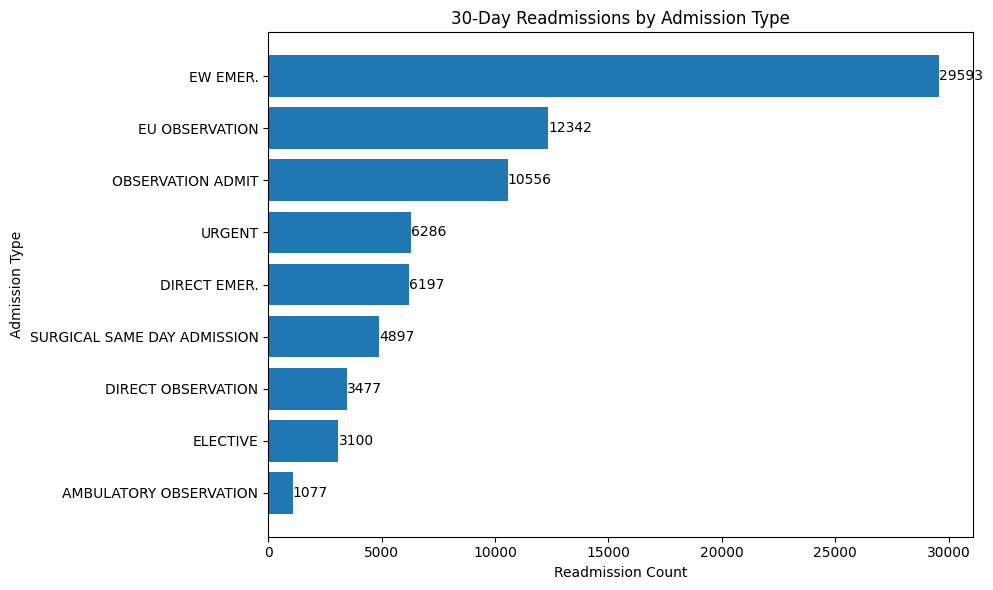

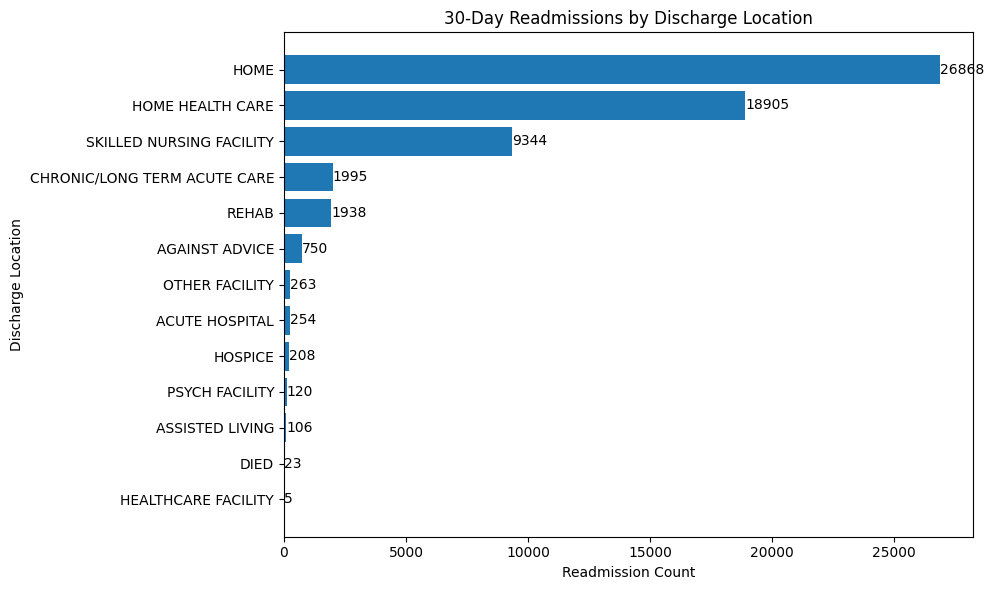

In [13]:
import matplotlib.pyplot as plt

# --- Plot 1: Readmissions by Admission Type ---
plt.figure(figsize=(10,6))

adm_counts = readmit_by_admission_type.sort_values("readmission_count", ascending=True)

bars = plt.barh(adm_counts["admission_type"], adm_counts["readmission_count"])

plt.title("30-Day Readmissions by Admission Type")
plt.xlabel("Readmission Count")
plt.ylabel("Admission Type")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.tight_layout()
plt.show()


# --- Plot 2: Readmissions by Discharge Location ---
plt.figure(figsize=(10,6))

dis_counts = readmit_by_discharge_location.sort_values("readmission_count", ascending=True)

bars = plt.barh(dis_counts["discharge_location"], dis_counts["readmission_count"])

plt.title("30-Day Readmissions by Discharge Location")
plt.xlabel("Readmission Count")
plt.ylabel("Discharge Location")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center')

plt.tight_layout()
plt.show()


In [14]:
admissions.info

<bound method DataFrame.info of         subject_id   hadm_id           admittime           dischtime  \
0         10000032  22595853 2180-05-06 22:23:00 2180-05-07 17:15:00   
1         10000032  22841357 2180-06-26 18:27:00 2180-06-27 18:49:00   
2         10000032  25742920 2180-08-05 23:44:00 2180-08-07 17:50:00   
3         10000032  29079034 2180-07-23 12:35:00 2180-07-25 17:55:00   
4         10000068  25022803 2160-03-03 23:16:00 2160-03-04 06:26:00   
...            ...       ...                 ...                 ...   
431083    19999828  25744818 2149-01-08 16:44:00 2149-01-18 17:00:00   
431084    19999828  29734428 2147-07-18 16:23:00 2147-08-04 18:10:00   
431085    19999840  21033226 2164-09-10 13:47:00 2164-09-17 13:42:00   
431086    19999840  26071774 2164-07-25 00:27:00 2164-07-28 12:15:00   
431087    19999987  23865745 2145-11-02 21:38:00 2145-11-11 12:57:00   

                  deathtime  admission_type      admission_location  \
0                       NaN     